# Preprocessing

### Extracting months and creating month_number column


In [2]:
import pandas as pd 
import numpy as np


In [2]:
df = pd.read_csv('/Users/market/Desktop/thesis_project/data/articles.csv')
df.head()

,title,link,date,views,shares,question,answer
0,Діни тұрғыда музыкалық аспаптарды сатудың үкімі,https://islam.kz/kk/questions/sauda-sattyq/din...,9 қазан 2023 ж. 14:57,2712,0,"Ассалямуалейкум! Ұстаз, өз гитараңды сатып жіб...",Әлхамдулилләһ. Уассаләту уәссәләму аля Расулил...
1,"Бір адамды өсектесе, одан кешірім сұрау керек пе?",https://islam.kz/kk/questions/arturli/bir-adam...,21 маусым 2025 ж. 15:06,399,0,"Ассаламуалейкум!Адамды сырттан өсектесе, ол ад...",Уағалейкумуссәләм уә рахматуллаһи уә бәракәтуһ...
2,Мұсылман емес елдерде шарап сынды харам заттар...,https://islam.kz/kk/questions/sauda-sattyq/mus...,19 маусым 2025 ж. 09:03,681,0,Ассаляму алейкум уа рахматуллахи уа баракятух!...,Уағалейкумуссәләм уә рахматуллаһи уә бәракәтуһ...
3,Әйелдің өз күйеуінің тегін (фамилиясын) алуы к...,https://islam.kz/kk/questions/januya/otbasy/ai...,17 маусым 2025 ж. 20:24,871,0,Ассаламуғалайкум! Әлеуметтік желіде көрдім еге...,Уағалейкумуссәләм уә рахматуллаһи уә бәракәтуһ...
4,Намаз бастау тәкбірінде «Аллаһу әкбар» дегенні...,https://islam.kz/kk/questions/qulshylyq/namaz/...,16 маусым 2025 ж. 16:03,691,0,Ассаляму алейкум уа рахматуллахи уа баракятух ...,Уағалейкумуссәләм уә рахматуллаһи уә бәракәтуһ...


In [4]:
df_ru = pd.read_csv('/Users/market/Desktop/thesis_project/data/articles_ru.csv')
df_ru.head()




,title,link,date,views,shares,question,answer,sources
0,Можно ли мусульманке выйти замуж за атеиста?,https://islam.kz/ru/questions/semya/nikyah/moj...,"22 декабря 2025 г., 15:09",481,0,А что если я выйду замуж за атеиста? Считается...,Бисмилляхир-рахманир-рахим\n\nСогласно исламск...,"¹ Священный Коран, сура «аль-Бакара», аят 221...."
1,«Можно ли носить часы на левой руке? Не против...,https://islam.kz/ru/questions/raznoe/mojno-li-...,"11 ноября 2025 г., 15:57",743,0,"Нурлыбек Сабыргалиев: Ассаляму алейкум, устаз!...",Бисмилляхир-рахманир-рахим. Ва алейкум ассалям...,1) Сподвижник Анаc (да будет доволен им Аллах)...
2,Разрешено ли в исламе праздновать Хэллоуин?,https://islam.kz/ru/questions/veroubejdenie/ra...,"31 октября 2025 г., 20:11",1019,0,Каково исламское отношение к празднованию Хэлл...,"«Хэллоуин»— это праздник, берущий свое начало ...",NaN
3,"«Раньше часто проклинал родственников, теперь ...",https://islam.kz/ru/questions/raznoe/ranshe-ch...,"28 октября 2025 г., 14:37",502,0,Ассаламу алейкум!Раньше у меня были конфликты ...,Бисмилляхир-рахманир-рахим\n\nУа алейкум ассал...,¹ Хадис: «Не проклинайте друг друга проклятием...
4,Проверка на инфекционные заболевания перед бра...,https://islam.kz/ru/questions/semya/nikyah/pro...,"25 октября 2025 г., 17:16",521,0,"Здравствуйте! Прошу прощения, я хотела бы выяс...","Во имя Аллаха, Милостивого, Милосердного (Бисм...",¹ «Европейский Совет по Фетвам и Исследованиям...


### Средняя длина фетв and summary


In [26]:
#kz
df = df[df['answer'].fillna('').str.split().str.len() > 1] #filter out empty answers

print(df['answer'].fillna('').str.split().str.len().describe())
print(df['title'].fillna('').str.split().str.len().describe())



count    2266.000000
mean      187.807590
std       162.077108
min         5.000000
25%        95.000000
50%       145.500000
75%       226.000000
max      2207.000000
Name: answer, dtype: float64
count    2266.000000
mean        8.437335
std         3.086652
min         2.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        21.000000
Name: title, dtype: float64


In [5]:
#ru
print(df_ru['answer'].fillna('').str.split().str.len().describe())
print(df_ru['title'].fillna('').str.split().str.len().describe())

count     313.000000
mean      251.380192
std       256.611985
min         7.000000
25%       117.000000
50%       177.000000
75%       296.000000
max      3028.000000
Name: answer, dtype: float64
count    313.000000
mean       7.782748
std        2.635572
min        3.000000
25%        6.000000
50%        7.000000
75%        9.000000
max       19.000000
Name: title, dtype: float64


In [6]:
df.dtypes

title       object
link        object
date        object
views        int64
shares       int64
question    object
answer      object
dtype: object

In [8]:
df.date.unique

<bound method Series.unique of 0         9 қазан 2023 ж. 14:57
1       21 маусым 2025 ж. 15:06
2       19 маусым 2025 ж. 09:03
3       17 маусым 2025 ж. 20:24
4       16 маусым 2025 ж. 16:03
                 ...           
2266     22 сәуір 2014 ж. 06:29
2267     22 сәуір 2014 ж. 06:21
2268     22 сәуір 2014 ж. 00:47
2269     22 сәуір 2014 ж. 00:05
2270     22 сәуір 2014 ж. 00:00
Name: date, Length: 2271, dtype: object>

In [4]:
df['date'] = df['date'].astype(str).str.lower()

df_ru['date'] = df_ru['date'].astype(str).str.lower()


In [19]:
df.columns

Index(['title', 'link', 'date', 'views', 'shares', 'question', 'answer',
       'month'],
      dtype='object')

In [ ]:
#for kazakh version
df_new = df

df_new['month_name'] = np.where(df['date'].str.contains('қаңтар', case = False, na = False), 'January', df['date'])
df_new['month_name'] = np.where(df['date'].str.contains('ақпан', case = False, na = False), 'February', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('наурыз', case = False, na = False), 'March', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('сәуір', case = False, na = False), 'April', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('мамыр', case = False, na = False), 'May', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('маусым', case = False, na = False), 'June', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('шілде', case = False, na = False), 'July', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('тамыз', case = False, na = False), 'August', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('қыркүйек', case = False, na = False), 'September', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('қазан', case = False, na = False), 'October', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('қараша', case = False, na = False), 'November', df['month_name'])
df_new['month_name'] = np.where(df['date'].str.contains('желтоқсан', case = False, na = False), 'December', df['month_name'])


In [7]:
#for russian version
df_new = df_ru

df_new['month_name'] = np.where(df_ru['date'].str.contains('январ', case = False, na = False), 'January', df_ru['date'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('феврал', case = False, na = False), 'February', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('март', case = False, na = False), 'March', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('апрел', case = False, na = False), 'April', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('мая', case = False, na = False), 'May', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('июн', case = False, na = False), 'June', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('июл', case = False, na = False), 'July', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('август', case = False, na = False), 'August', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('сентяб', case = False, na = False), 'September', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('октябр', case = False, na = False), 'October', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('нояб', case = False, na = False), 'November', df_ru['month_name'])
df_new['month_name'] = np.where(df_ru['date'].str.contains('декаб', case = False, na = False), 'December', df_ru['month_name'])

In [8]:
# Создаём словарь для сопоставления месяцев с номерами
month_to_number = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

In [9]:
df_new['month'] = df_new['month_name'].map(month_to_number)


*Объяснение*

**month_to_number**: Словарь, где ключи — названия месяцев, а значения — их номера (от 1 до 12).


**.map(month_to_number)**: Применяет словарь к каждому значению в колонке month, создавая новую колонку month_number. Если в month встречаются значения, не указанные в словаре (например, NaN или неверные строки), результат будет NaN.

### Extracting years and days

In [10]:
df_new['year'] = df_new['date'].str.extract(r'(\d{4})').astype(int)

In [11]:
df_new['day'] = df_new['date'].str.extract(r'(\d*)').astype(int)

### Creating new dates column

In [12]:
df_new['date_new'] = pd.to_datetime(df_new[['year', 'month', 'day']])

In [13]:
#Column of the parsing date

import datetime

parsing_date = datetime.datetime(2026, 1, 8)

df_new['parsing_date'] = parsing_date

### Count distribution by years 

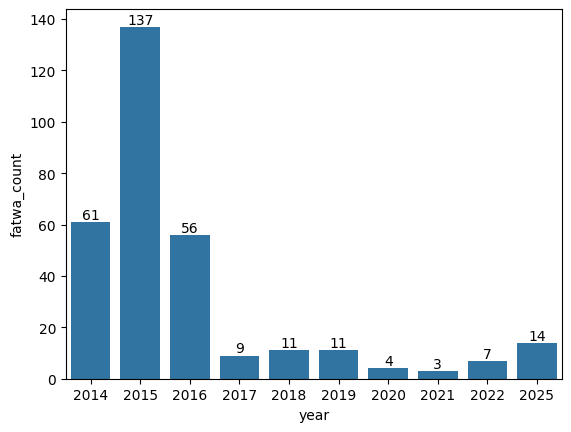

In [14]:
import seaborn as sns

df_years = df_new \
    .groupby('year', as_index=False) \
    .agg({'title':'count'}) \
    .rename(columns={'title':'fatwa_count'})

ax = sns.barplot(df_years, x = 'year', y = 'fatwa_count', estimator="sum", errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10);


In [ ]:
#df_new.to_csv('/Users/market/Desktop/thesis_project/data/df_new1.csv', index=False) #kazakh version



#df_new.to_csv('/Users/market/Desktop/thesis_project/data/df_new1_ru.csv', index=False) #russian version




### How many days passed from posting date to today?

In [15]:
import datetime
import pandas as pd 
import numpy as np

In [17]:
df = pd.read_csv('/Users/market/Desktop/thesis_project/data/df_new1_ru.csv')



In [11]:
df.dtypes

title           object
link            object
date            object
views            int64
shares           int64
question        object
answer          object
month_name      object
month            int64
year             int64
day              int64
date_new        object
parsing_date    object
dtype: object

In [18]:
df['days_passed'] = (pd.to_datetime(df['parsing_date']) - pd.to_datetime(df['date_new'])).dt.days

In [ ]:
df

### The months by Islamic calendar

In [19]:
from hijri_converter import convert

/var/folders/bz/hf_1w8cn61n21ccgg_ms6fg40000gp/T/ipykernel_3950/2635783276.py:1: DeprecationWarning: hijri-converter is deprecated. Use 'hijridate' instead: pip install hijridate==2.3.0
  from hijri_converter import convert


In [20]:
# словарь для названий месяцев
hijri_months = {
    1: "Muharram",
    2: "Safar",
    3: "Rabi al-Awwal",
    4: "Rabi al-Thani",
    5: "Jumada al-Awwal",
    6: "Jumada al-Thani",
    7: "Rajab",
    8: "Sha'ban",
    9: "Ramadan",
    10: "Shawwal",
    11: "Dhu al-Qi'dah",
    12: "Dhu al-Hijjah"
}

df["date_new"] = pd.to_datetime(df["date_new"], errors="coerce")

df["hijri_month"] = df["date_new"].apply(
    lambda d: hijri_months[convert.Gregorian(d.year, d.month, d.day).to_hijri().month]
)


In [ ]:
#df.to_csv('/Users/market/Desktop/thesis_project/data/df_new2_ru.csv', index=False)

In [28]:
import pandas as pd 
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer #for multilingual data
import string
import re

In [29]:
custom_punctuation = string.punctuation + '«»'

def preprocess_text(text):
      
     # Guard against NaN / non-string inputs
    if pd.isna(text):
        return ''

        
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and «» 
    text = text.translate(str.maketrans('', '', custom_punctuation))    

    # Remove extra spaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()

    #Remove numbers
    text = re.sub(r'\d+', '', text)
    
    return text

# Apply preprocessing to the 'titles' column
df['title'] = df['title'].apply(preprocess_text)
df['answer'] = df['answer'].apply(preprocess_text)
df['question'] = df['question'].apply(preprocess_text)

In [30]:
df.to_csv('/Users/market/Desktop/thesis_project/data/df_new2_ru.csv', index=False)